# 07 — Customer Segmentation
RFM-style behavioral segmentation: Recency, Frequency, and Monetary value.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations/segmentation')
OUT.mkdir(parents=True, exist_ok=True)
source = PROCESSED / 'final_dataset.csv'
if not source.exists(): source = PROCESSED / 'cleaned_transactions.csv'
if not source.exists(): raise FileNotFoundError('Run the cleaning notebook first.')
df = pd.read_csv(source)

def find(candidates, required=True):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None: raise KeyError(f'Expected one of {candidates}')
    return col

customer = find(['customer_id', 'customerId', 'client_id'])
transaction = find(['transaction_id', 'transactionId', 'id'], required=False)
amount = find(['amount_usd', 'amount', 'transaction_amount', 'value'])
date = find(['transaction_date', 'date', 'created_at'])
status = find(['transaction_status', 'status'], required=False)
df[date] = pd.to_datetime(df[date], errors='coerce')
df = df[df[date].notna()].copy()
if status:
    valid = df[df[status].astype(str).str.lower().isin(['completed','complete','success','successful'])].copy()
    if valid.empty: valid = df.copy()
else: valid = df.copy()
reference_date = valid[date].max()

C:\Users\user\AppData\Local\Temp\ipykernel_31532\1002086754.py:11: DtypeWarning: Columns (13,36,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(source)


In [2]:
frequency_agg = (transaction, 'nunique') if transaction else (amount, 'size')
rfm = valid.groupby(customer).agg(
    recency_days=(date, lambda s: (reference_date - s.max()).days),
    frequency=frequency_agg,
    monetary=(amount, 'sum')
).reset_index()
rfm['r_score'] = pd.qcut(rfm['recency_days'].rank(method='first', ascending=False), 5, labels=False, duplicates='drop') + 1
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=False, duplicates='drop') + 1
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=False, duplicates='drop') + 1
rfm['rfm_score'] = rfm[['r_score','f_score','m_score']].sum(axis=1)
rfm['segment'] = pd.cut(rfm['rfm_score'], bins=[0, 5, 8, 11, 13, 15], labels=['Low Activity','Occasional','Active','Loyal','High Value'])
rfm.to_csv(PROCESSED / 'customer_rfm_segments.csv', index=False)
rfm.head()

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,C0000001,1,2981,574419.37,1,4,4,9,Active
1,C0000002,0,2404,589588.84,1,3,5,9,Active
2,C0000003,1,1813,299860.10,1,2,3,6,Occasional
3,C0000004,0,4745,860391.91,1,5,5,11,Active
4,C0000005,0,2058,198670.86,1,3,2,6,Occasional


In [3]:
segment_summary = rfm.groupby('segment', observed=False).agg(customers=(customer,'nunique'), total_monetary=('monetary','sum'), average_monetary=('monetary','mean')).reset_index()
segment_summary['customer_share_pct'] = segment_summary['customers'].div(len(rfm)).mul(100)
segment_summary['value_share_pct'] = segment_summary['total_monetary'].div(rfm['monetary'].sum()).mul(100)
segment_summary.to_csv(PROCESSED / 'segment_summary.csv', index=False)
segment_summary

,segment,customers,total_monetary,average_monetary,customer_share_pct,value_share_pct
0,Low Activity,31,2544987.30,82096.364516,15.5,3.362899
1,Occasional,49,9182206.22,187391.963673,24.5,12.133197
2,Active,67,25986034.63,387851.263134,33.5,34.337463
3,Loyal,41,28056124.60,684295.721951,20.5,37.072842
4,High Value,12,9909023.10,825751.925000,6.0,13.093599


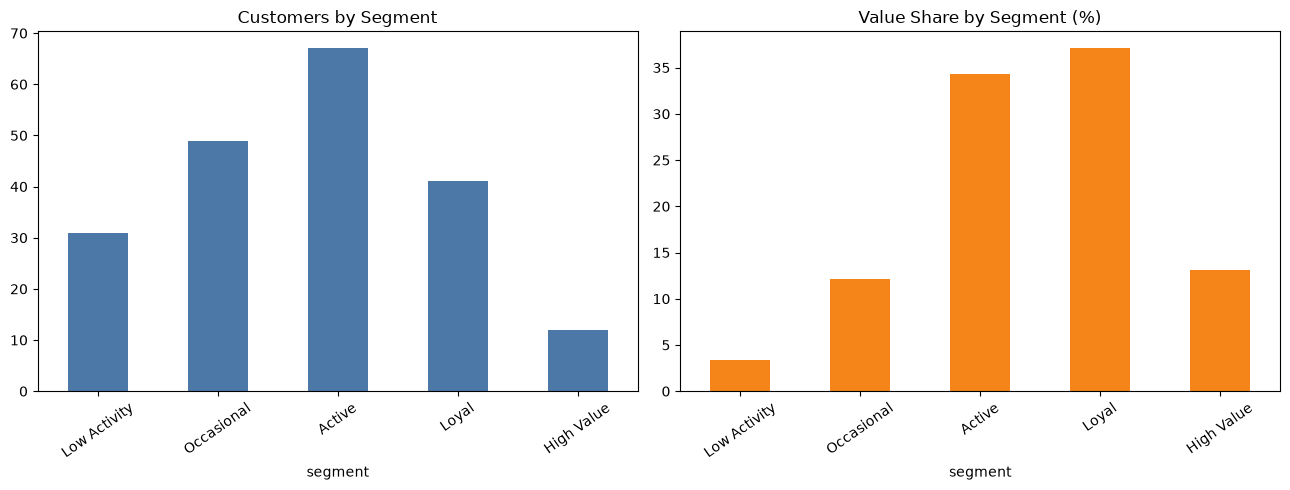

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
segment_summary.plot.bar(x='segment', y='customers', legend=False, ax=axes[0], color='#4c78a8')
axes[0].set_title('Customers by Segment')
axes[0].tick_params(axis='x', rotation=35)
segment_summary.plot.bar(x='segment', y='value_share_pct', legend=False, ax=axes[1], color='#f58518')
axes[1].set_title('Value Share by Segment (%)')
axes[1].tick_params(axis='x', rotation=35)
fig.tight_layout()
fig.savefig(OUT / 'segment_profile.png', dpi=150)
plt.show()
plt.close(fig)

## Segment interpretation
- High Value: high combined RFM score.
- Loyal: strong frequency and monetary behavior.
- Active: currently engaged but not necessarily top value.
- Occasional: moderate or inconsistent behavior.
- Low Activity: weak recency, frequency, and/or monetary value.
هذه شرائح سلوكية وليست أحكاماً ائتمانية أو تنبؤاً بمستقبل العميل.